![Banner](../../images/04_banner.png)


# 4.7 Bridges

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.7 of 8)

**Dataset:** `data_1998_2010_long_lbc.csv` + `US_COUNTY.shp` (3,107 counties, 1998 vs. 2012); `diabetes_northeast.shp` (217 counties)

**Focus:** Two direct previews — space-time clustering (Part 9) and small-area rate instability (Part 5)

**Library:** `spatialstats.cluster` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Bridge 1: From Static to Emerging Hot Spots](#3.-Bridge-1:-From-Static-to-Emerging-Hot-Spots)

4. [Bridge 2: From Raw Rates to Population-Adjusted Risk](#4.-Bridge-2:-From-Raw-Rates-to-Population-Adjusted-Risk)

5. [Summary and Conclusions](#5.-Summary-and-Conclusions)

6. [Resources](#6.-Resources)


***
## 1. Overview

Every method in Chapters 4.2–4.6 answers a **purely spatial** question at a **single point in time**, using
**raw rates or counts** exactly as reported. Both of those simplifications are deliberate scoping choices for
this Part, and both are lifted in later Parts. This short chapter runs two small, concrete demonstrations —
not full treatments — of what changes when each simplification is removed, so the connection to Part 9
(space-time) and Part 5 (population-adjusted smoothing) is a worked preview rather than an abstract promise.

| Step | What we do |
|------|------------|
| Bridge 1 | Run Gi* at two time points 14 years apart on the same national county graph, and classify counties as emerging, diminishing, or persistent hot spots — the static building block of Part 9's *emerging hot spot analysis* |
| Bridge 2 | Show directly, with a simple standard-error calculation, why small-population counties produce noisier rate estimates — the motivating problem Part 5's empirical Bayes and BYM methods are built to solve |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.cluster import getis_ord_gi

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Bridge 1: From Static to Emerging Hot Spots

Every Gi* map in this Part answers "where are the hot spots **right now**". Part 3, Chapter 3.4 already used
the national county mortality panel (`data_1998_2010_long_lbc.csv`, 3,107 counties, 1998–2012) to show that
*change itself* is spatially autocorrelated. The natural next question for cluster analysis specifically:
**do the same counties stay hot spots over time, or does the hot-spot map itself move?**

In [2]:
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
us_county = gpd.read_file(DATA / "US_COUNTY.shp")

rate_1998 = panel.loc[panel["Year"] == 1998, ["FIPS", "RATE"]].rename(columns={"RATE": "RATE_1998"})
rate_2012 = panel.loc[panel["Year"] == 2012, ["FIPS", "RATE"]].rename(columns={"RATE": "RATE_2012"})
national = us_county.merge(rate_1998, on="FIPS", how="inner").merge(rate_2012, on="FIPS", how="inner")
w_national = Queen(national)
print(f"{len(national)} counties matched, {len(w_national.islands())} islands")

3107 counties matched, 2 islands


In [3]:
gi_1998 = getis_ord_gi(national["RATE_1998"], w_national, star=True, inference="analytic", correction="fdr")
gi_2012 = getis_ord_gi(national["RATE_2012"], w_national, star=True, inference="analytic", correction="fdr")
print(f"1998: {gi_1998.hot.sum()} hot spots, {gi_1998.cold.sum()} cold spots")
print(f"2012: {gi_2012.hot.sum()} hot spots, {gi_2012.cold.sum()} cold spots")

1998: 594 hot spots, 631 cold spots
2012: 502 hot spots, 522 cold spots


Comparing the two hot-spot masks directly gives the basic vocabulary of **emerging hot spot analysis**
(formally developed in Part 9 with many more time steps and a proper trend classification):

In [4]:
emerging = gi_2012.hot & ~gi_1998.hot        # newly hot in 2012, was not hot in 1998
diminishing = gi_1998.hot & ~gi_2012.hot     # was hot in 1998, no longer hot in 2012
persistent = gi_1998.hot & gi_2012.hot       # hot in both years

print(f"emerging hot spots   (new in 2012)      : {emerging.sum()}")
print(f"diminishing hot spots (gone by 2012)     : {diminishing.sum()}")
print(f"persistent hot spots  (hot in both years) : {persistent.sum()}")

emerging hot spots   (new in 2012)      : 48
diminishing hot spots (gone by 2012)     : 140
persistent hot spots  (hot in both years) : 454


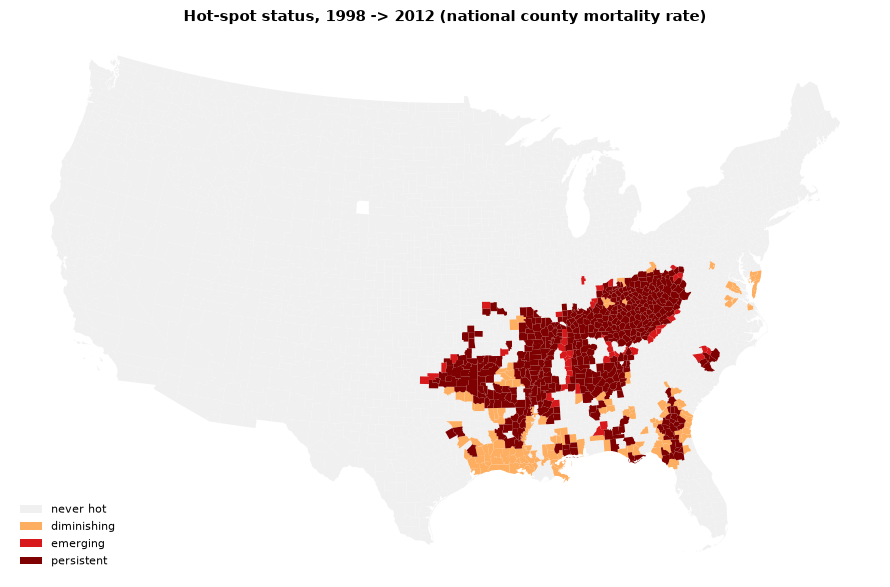

In [5]:
status = np.full(len(national), "never hot", dtype=object)
status[persistent] = "persistent"
status[emerging] = "emerging"
status[diminishing] = "diminishing"

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"never hot": "#f0f0f0", "diminishing": "#fdae61", "emerging": "#d7191c", "persistent": "#7f0000"}
plot_df = national.assign(status=status)
for lab, col in colors.items():
    sub = plot_df[plot_df["status"] == lab]
    if len(sub):
        sub.plot(ax=ax, color=col, linewidth=0)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in colors.items()], loc="lower left", fontsize=8)
ax.set_axis_off()
ax.set_title("Hot-spot status, 1998 -> 2012 (national county mortality rate)")
plt.tight_layout()
plt.show()

Most hot spots (454 of 502 in 1998) are **persistent** — geography changes slowly, and the same broad regions
remain elevated across 14 years. But 48 counties newly *emerged* as hot spots by 2012, and 140 that were hot in
1998 had *diminished* by 2012. A single static Gi* map — the only kind this Part builds — cannot distinguish a
newly emerging problem from a long-persistent one; Part 9's formal space-time framework classifies trajectories
like these systematically, testing directly for statistically meaningful emergence or decline rather than the
simple two-snapshot comparison shown here.

***
## 4. Bridge 2: From Raw Rates to Population-Adjusted Risk

Every rate used throughout this Part — `Dia_pct`, the cancer `rate`, the mortality `RATE` — is a **raw observed
rate**: cases divided by population, with no adjustment for how reliably that division was estimated. A rate
computed from a small population is inherently noisier than the same rate computed from a large one, purely
from sampling variability — nothing to do with real geographic differences.

In [6]:
g = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(g)
gi = getis_ord_gi(g["Dia_pct"], w, star=True, inference="analytic", correction="fdr")
flagged = gi.hot | gi.cold
print(f"population of Gi*-flagged counties  : median {g.loc[flagged, 'POP_Total'].median():,.0f}")
print(f"population of unflagged counties    : median {g.loc[~flagged, 'POP_Total'].median():,.0f}")
print(f"smallest flagged county: {g.loc[flagged].sort_values('POP_Total').iloc[0][['COUNTY', 'POP_Total']].to_dict()}")

population of Gi*-flagged counties  : median 57,989
population of unflagged counties    : median 106,017
smallest flagged county: {'COUNTY': 'Lewis County', 'POP_Total': 26469.2}


The standard error of a rate estimate scales as $\sqrt{p(1-p)/n}$ — a purely statistical fact, independent of
geography:

In [7]:
p = 0.08  # a representative diabetes prevalence
for pop in (5_000, 50_000, 500_000):
    se = np.sqrt(p * (1 - p) / pop)
    print(f"population = {pop:>9,}: standard error of the rate = {se:.5f}  "
          f"(95% CI width ≈ ±{1.96 * se:.4f})")

population =     5,000: standard error of the rate = 0.00384  (95% CI width ≈ ±0.0075)
population =    50,000: standard error of the rate = 0.00121  (95% CI width ≈ ±0.0024)
population =   500,000: standard error of the rate = 0.00038  (95% CI width ≈ ±0.0008)


A 100-fold difference in population produces a **10-fold** difference in the standard error of the same
underlying rate. Every method in this Part — Gi*, LISA, the scan statistic — is applied to `Dia_pct` exactly as
reported, treating a county of 26,000 people and a county of 2.6 million people as equally precise
measurements. They are not: a small county's extreme rate is more likely to be sampling noise dressed up as a
genuine finding, and a hot-spot or cluster analysis run on raw rates inherits that noise directly. **Part 5**
builds the fix — empirical Bayes and BYM smoothing that explicitly shrink small-population estimates toward a
more stable regional or global value, in proportion to how much statistical weight their population actually
supports — turning this chapter's informal population check into a formal, integrated part of the estimation
itself rather than an afterthought applied to already-computed raw rates.

***
## 5. Summary and Conclusions

This short chapter worked two concrete previews of what Parts 5 and 9 add on top of everything built in Part 4.

### What we did

1. **Space-time bridge:** ran Gi* on the same national county graph at two time points 14 years apart, and
   classified 502 hot spots in 2012 into persistent (454), emerging (48), and, from 1998's perspective,
   diminishing (140) — the basic building block Part 9 develops into a full space-time framework.
2. **Population-adjustment bridge:** showed directly that a 100-fold difference in county population produces a
   10-fold difference in the standard error of the same rate, and confirmed the smallest Gi*-flagged county in
   this Part's own data has a population under 27,000 — motivating Part 5's empirical Bayes and BYM smoothing.

### Practical takeaways

- A single-snapshot hot-spot map cannot say whether a flagged area is a new or a long-standing problem; treat
  any one-time cluster analysis as a snapshot, not a trend statement, unless it is explicitly repeated over
  time.
- Every raw-rate method in this Part is silently more vulnerable to false positives in small-population areas;
  a flagged small county deserves extra scrutiny (or, better, Part 5's smoothing) before being reported as a
  confirmed finding.

### Next steps

**Chapter 4.8 (Exercises)** closes Part 4 with five solved problems spanning Chapters 4.2 through 4.6.

***
## 6. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Ord, J. K. & Getis, A. (2012). Local spatial heteroscedasticity (LOSH). *Journal of Geographical Systems*, 14, 1–14. | Background on rate-variance issues connected to Bridge 2 |
| Clarke, K. C. (2014). *Getting Started with Geographic Information Systems* (5th ed.). Pearson. | Accessible framing of space-time and small-area estimation as extensions of static cluster analysis |

### Key papers

| Paper | Contribution |
|---|---|
| Getis, A. & Ord, J. K. (1996). Local spatial statistics: an overview. In *Spatial Analysis: Modelling in a GIS Environment*. | The static Gi* framework extended by Part 9 |
| Clayton, D. & Kaldor, J. (1987). Empirical Bayes estimates of age-standardized relative risks for use in disease mapping. *Biometrics*, 43, 671–681. | Origin of the empirical Bayes approach previewed in Bridge 2, developed fully in Part 5 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.getis_ord_gi` | Reused at two time points for Bridge 1 |
| Part 5 | `spatialstats.bayes` — the full empirical Bayes / BYM treatment of Bridge 2 |
| Part 9 | Space-time scan statistics and emerging hot spot analysis, the full treatment of Bridge 1 |